In [9]:
import pandas as pd
import numpy as np


In [2]:
%pip install matplotlib


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mysql.connector

In [17]:
connection = mysql.connector.connect(
    host="localhost",
    user="root",
    password="satyam@2006",
    database="healthcare"
)

print("Database connected successfully!")

Database connected successfully!


In [18]:
patients = pd.read_sql(
    "SELECT * FROM patients",
    connection
)

patients.head()

C:\Users\dubey\AppData\Local\Temp\ipykernel_17164\3782285325.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  patients = pd.read_sql(


,patient_id,first_name,last_name,gender,date_of_birth,city,registration_date
0,1,Karan,Sharma,Male,1984-09-03,Mumbai,2024-04-02
1,2,Mohit,Dubey,Male,1967-10-19,Varanasi,2025-05-14
2,3,Aditya,Sharma,Male,1968-05-28,Mumbai,2024-04-21
3,4,Shreya,Kapoor,Female,1962-05-19,Chandigarh,2024-02-12
4,5,Muskan,Saxena,Female,1979-10-11,Lucknow,2026-04-21


In [19]:
gender_count = patients["gender"].value_counts()

print(gender_count)

gender
Male      759
Female    241
Name: count, dtype: int64


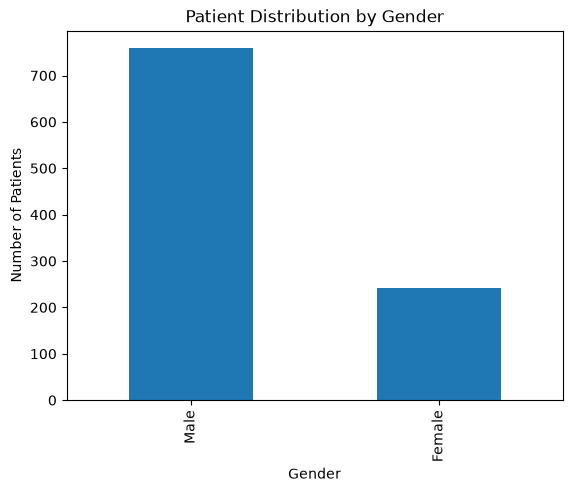

In [20]:
gender_count.plot(
    kind="bar",
    title="Patient Distribution by Gender"
)

plt.xlabel("Gender")
plt.ylabel("Number of Patients")
plt.show()

In [21]:
city_count = patients["city"].value_counts()

print(city_count)

city
Bengaluru     113
Noida         113
Gurugram      110
Jaipur        107
Varanasi      104
Chandigarh    103
Pune           97
Lucknow        88
Mumbai         86
Delhi          79
Name: count, dtype: int64


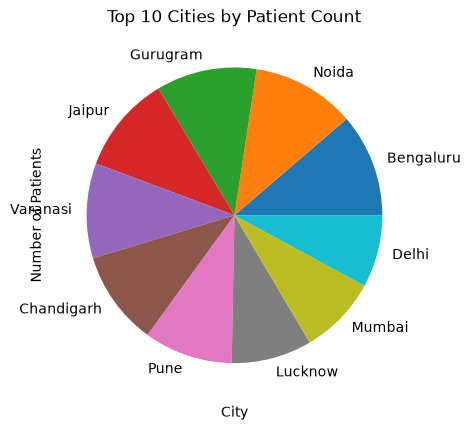

In [24]:
city_count.head(10).plot(
    kind="pie",
    title="Top 10 Cities by Patient Count"
)

plt.xlabel("City")
plt.ylabel("Number of Patients")
plt.xticks(rotation=90)
plt.show()

In [25]:
patients["date_of_birth"] = pd.to_datetime(patients["date_of_birth"])


today = pd.Timestamp.today()

patients["age"] = (
    (today - patients["date_of_birth"]).dt.days / 365.25
).astype(int)

patients[["first_name", "date_of_birth", "age"]].head(10)

bins = [0, 18, 35, 60, 100]
labels = ["0-18", "19-35", "36-60", "61+"]

patients["age_group"] = pd.cut(
    patients["age"],
    bins=bins,
    labels=labels
)

age_group_count = patients["age_group"].value_counts().sort_index()

print(age_group_count)

age_group
0-18       0
19-35    340
36-60    546
61+      114
Name: count, dtype: int64


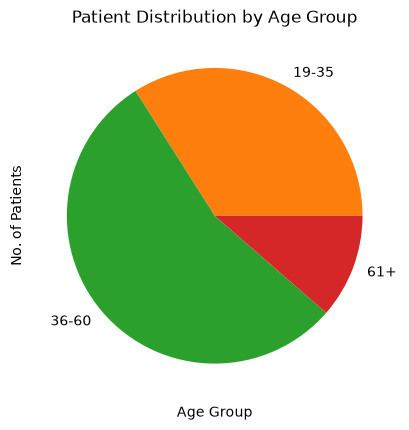

In [26]:
age_group_count.plot(
    kind="pie",
    title="Patient Distribution by Age Group"
)

plt.xlabel("Age Group")
plt.ylabel("No. of Patients")
plt.show()